# Dunnhumby - The Complete Journey : 데이터 탐색 (분포 확인용, EDA 아님)

**목적**: 본격 EDA 전, 8개 테이블이 각각 어떤 값을 담고 있는지 / 결측이 얼마나 되는지 / 총매출 추이가 어떤 모양인지만 빠르게 확인.

**파일 위치**: `data/` 폴더 아래에 Kaggle 원본 8개 CSV가 있다고 가정합니다.
- transaction_data.csv
- hh_demographic.csv
- product.csv
- campaign_table.csv
- campaign_desc.csv
- coupon.csv
- coupon_redempt.csv
- causal_data.csv

파일명이 다르면 아래 `DATA_DIR`, `FILES` 딕셔너리만 수정하면 됩니다.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

DATA_DIR = "data/"

FILES = {
    "transaction_data": "transaction_data.csv",
    "hh_demographic":   "hh_demographic.csv",
    "product":          "product.csv",
    "campaign_table":   "campaign_table.csv",
    "campaign_desc":    "campaign_desc.csv",
    "coupon":           "coupon.csv",
    "coupon_redempt":   "coupon_redempt.csv",
    "causal_data":      "causal_data.csv",
}


In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 시스템에 설치된 한글 폰트 자동 탐색 (Windows 기준 '맑은 고딕' 우선)
candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available = {f.name for f in fm.fontManager.ttflist}

font_name = next((c for c in candidates if c in available), None)

if font_name:
    plt.rcParams["font.family"] = font_name
else:
    print("한글 폰트를 찾지 못했습니다. 나눔고딕 설치 필요: https://hangeul.naver.com/font 에서 다운로드 후 재시작")

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

## 1. 전체 로드 및 shape 한눈에 보기

In [3]:
dfs = {}
for name, fname in FILES.items():
    dfs[name] = pd.read_csv(DATA_DIR + fname)

summary_rows = []
for name, df in dfs.items():
    summary_rows.append({
        "table": name,
        "rows": len(df),
        "cols": df.shape[1],
        "memory_MB": round(df.memory_usage(deep=True).sum() / 1024**2, 1),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("rows", ascending=False)
summary_df


,table,rows,cols,memory_MB
7,causal_data,36786524,5,1473.5
0,transaction_data,2595732,12,237.6
5,coupon,124548,3,2.9
2,product,92353,7,9.5
3,campaign_table,7208,3,0.2
6,coupon_redempt,2318,4,0.1
1,hh_demographic,801,8,0.1
4,campaign_desc,30,4,0.0


## 2. 테이블별 상세 확인

각 테이블마다 다음을 순서대로 본다:
1. `head()` — 실제 값 모양
2. `dtypes` — 타입이 기대한 대로 들어왔는지 (특히 ID류가 object로 안 깨졌는지)
3. 결측치 비율
4. 수치형 컬럼 `describe()`
5. 범주형 컬럼은 `value_counts()` 상위 값


In [4]:
def inspect(name):
    df = dfs[name]
    print(f"===== {name}  (shape: {df.shape}) =====\n")

    print("--- head(3) ---")
    display(df.head(3))

    print("\n--- dtypes ---")
    print(df.dtypes)

    print("\n--- 결측치 비율(%) ---")
    na_ratio = (df.isna().sum() / len(df) * 100).round(2)
    print(na_ratio[na_ratio > 0] if na_ratio.sum() > 0 else "결측 없음")

    num_cols = df.select_dtypes(include=np.number).columns
    if len(num_cols) > 0:
        print("\n--- 수치형 describe ---")
        display(df[num_cols].describe().T)

    cat_cols = df.select_dtypes(include='object').columns
    for c in cat_cols:
        nunique = df[c].nunique()
        print(f"\n--- '{c}' 고유값 {nunique}개, 상위 10개 ---")
        print(df[c].value_counts().head(10))

    print("\n")


In [5]:
inspect("transaction_data")

===== transaction_data  (shape: (2595732, 12)) =====

--- head(3) ---


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.6,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.0,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.3,1631,1,0.0,0.0



--- dtypes ---
household_key          int64
BASKET_ID              int64
DAY                    int64
PRODUCT_ID             int64
QUANTITY               int64
SALES_VALUE          float64
STORE_ID               int64
RETAIL_DISC          float64
TRANS_TIME             int64
WEEK_NO                int64
COUPON_DISC          float64
COUPON_MATCH_DISC    float64
dtype: object

--- 결측치 비율(%) ---
결측 없음

--- 수치형 describe ---


,count,mean,std,min,25%,50%,75%,max
household_key,2595732.0,1.271953e+03,7.260660e+02,1.000000e+00,6.560000e+02,1.272000e+03,1.913000e+03,2.500000e+03
BASKET_ID,2595732.0,3.402620e+10,4.711649e+09,2.698485e+10,3.040805e+10,3.276081e+10,4.012685e+10,4.230536e+10
DAY,2595732.0,3.887562e+02,1.897210e+02,1.000000e+00,2.290000e+02,3.900000e+02,5.530000e+02,7.110000e+02
PRODUCT_ID,2595732.0,2.891435e+06,3.837404e+06,2.567100e+04,9.174590e+05,1.028816e+06,1.133018e+06,1.831630e+07
QUANTITY,2595732.0,1.004286e+02,1.153436e+03,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,8.963800e+04
SALES_VALUE,2595732.0,3.104120e+00,4.182274e+00,0.000000e+00,1.290000e+00,2.000000e+00,3.490000e+00,8.400000e+02
STORE_ID,2595732.0,3.142673e+03,8.937113e+03,1.000000e+00,3.300000e+02,3.720000e+02,4.220000e+02,3.428000e+04
RETAIL_DISC,2595732.0,-5.387054e-01,1.249191e+00,-1.800000e+02,-6.900000e-01,-1.000000e-02,0.000000e+00,3.990000e+00
TRANS_TIME,2595732.0,1.561586e+03,3.998378e+02,0.000000e+00,1.308000e+03,1.613000e+03,1.843000e+03,2.359000e+03
WEEK_NO,2595732.0,5.622150e+01,2.710223e+01,1.000000e+00,3.300000e+01,5.600000e+01,8.000000e+01,1.020000e+02


In [6]:
inspect("hh_demographic")

===== hh_demographic  (shape: (801, 8)) =====

--- head(3) ---


,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8



--- dtypes ---
AGE_DESC                 str
MARITAL_STATUS_CODE      str
INCOME_DESC              str
HOMEOWNER_DESC           str
HH_COMP_DESC             str
HOUSEHOLD_SIZE_DESC      str
KID_CATEGORY_DESC        str
household_key          int64
dtype: object

--- 결측치 비율(%) ---
결측 없음

--- 수치형 describe ---


,count,mean,std,min,25%,50%,75%,max
household_key,801.0,1235.17603,736.804647,1.0,596.0,1218.0,1914.0,2499.0



--- 'AGE_DESC' 고유값 6개, 상위 10개 ---
AGE_DESC
45-54    288
35-44    194
25-34    142
65+       72
55-64     59
19-24     46
Name: count, dtype: int64

--- 'MARITAL_STATUS_CODE' 고유값 3개, 상위 10개 ---
MARITAL_STATUS_CODE
U    344
A    340
B    117
Name: count, dtype: int64

--- 'INCOME_DESC' 고유값 12개, 상위 10개 ---
INCOME_DESC
50-74K       192
35-49K       172
75-99K        96
25-34K        77
15-24K        74
Under 15K     61
125-149K      38
100-124K      34
150-174K      30
250K+         11
Name: count, dtype: int64

--- 'HOMEOWNER_DESC' 고유값 5개, 상위 10개 ---
HOMEOWNER_DESC
Homeowner          504
Unknown            233
Renter              42
Probable Renter     11
Probable Owner      11
Name: count, dtype: int64

--- 'HH_COMP_DESC' 고유값 6개, 상위 10개 ---
HH_COMP_DESC
2 Adults No Kids    255
2 Adults Kids       187
Single Female       144
Single Male          95
Unknown              73
1 Adult Kids         47
Name: count, dtype: int64

--- 'HOUSEHOLD_SIZE_DESC' 고유값 5개, 상위 10개 ---
HOUSEHOLD_SIZE_DESC
2

C:\Users\spide\AppData\Local\Temp\ipykernel_10604\274139065.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [7]:
inspect("product")

===== product  (shape: (92353, 7)) =====

--- head(3) ---


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,



--- dtypes ---
PRODUCT_ID              int64
MANUFACTURER            int64
DEPARTMENT                str
BRAND                     str
COMMODITY_DESC            str
SUB_COMMODITY_DESC        str
CURR_SIZE_OF_PRODUCT      str
dtype: object

--- 결측치 비율(%) ---
결측 없음

--- 수치형 describe ---


,count,mean,std,min,25%,50%,75%,max
PRODUCT_ID,92353.0,5.328353e+06,5.359937e+06,25671.0,970628.0,1621091.0,9704770.0,18316298.0
MANUFACTURER,92353.0,1.739228e+03,1.818270e+03,1.0,328.0,1094.0,2264.0,6477.0



--- 'DEPARTMENT' 고유값 44개, 상위 10개 ---
DEPARTMENT
GROCERY       39021
DRUG GM       31529
PRODUCE        3118
COSMETICS      3011
NUTRITION      2914
MEAT           2544
MEAT-PCKGD     2427
DELI           2354
PASTRY         2149
FLORAL          938
Name: count, dtype: int64

--- 'BRAND' 고유값 2개, 상위 10개 ---
BRAND
National    78537
Private     13816
Name: count, dtype: int64

--- 'COMMODITY_DESC' 고유값 308개, 상위 10개 ---
COMMODITY_DESC
GREETING CARDS/WRAP/PARTY SPLY    2785
CANDY - PACKAGED                  2475
MAKEUP AND TREATMENT              2467
HAIR CARE PRODUCTS                1744
SOFT DRINKS                       1704
BAG SNACKS                        1523
HISPANIC                          1460
FRZN MEAT/MEAT DINNERS            1268
STATIONERY & SCHOOL SUPPLIES      1261
MAGAZINE                          1224
Name: count, dtype: int64

--- 'SUB_COMMODITY_DESC' 고유값 2383개, 상위 10개 ---
SUB_COMMODITY_DESC
CARDS EVERYDAY            1005
BEERALEMALT LIQUORS        833
SPICES & SEASONINGS   

C:\Users\spide\AppData\Local\Temp\ipykernel_10604\274139065.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [8]:
inspect("campaign_table")

===== campaign_table  (shape: (7208, 3)) =====

--- head(3) ---


,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26



--- dtypes ---
DESCRIPTION        str
household_key    int64
CAMPAIGN         int64
dtype: object

--- 결측치 비율(%) ---
결측 없음

--- 수치형 describe ---


,count,mean,std,min,25%,50%,75%,max
household_key,7208.0,1268.696726,731.936391,1.0,644.0,1263.0,1924.0,2500.0
CAMPAIGN,7208.0,15.659545,6.949705,1.0,9.0,14.0,20.0,30.0



--- 'DESCRIPTION' 고유값 3개, 상위 10개 ---
DESCRIPTION
TypeA    3979
TypeB    2655
TypeC     574
Name: count, dtype: int64




C:\Users\spide\AppData\Local\Temp\ipykernel_10604\274139065.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [9]:
inspect("campaign_desc")

===== campaign_desc  (shape: (30, 4)) =====

--- head(3) ---


,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691



--- dtypes ---
DESCRIPTION      str
CAMPAIGN       int64
START_DAY      int64
END_DAY        int64
dtype: object

--- 결측치 비율(%) ---
결측 없음

--- 수치형 describe ---


,count,mean,std,min,25%,50%,75%,max
CAMPAIGN,30.0,15.500000,8.803408,1.0,8.25,15.5,22.75,30.0
START_DAY,30.0,463.866667,134.488490,224.0,360.00,470.0,584.00,659.0
END_DAY,30.0,510.466667,137.730555,264.0,405.75,502.0,640.25,719.0



--- 'DESCRIPTION' 고유값 3개, 상위 10개 ---
DESCRIPTION
TypeB    19
TypeC     6
TypeA     5
Name: count, dtype: int64




C:\Users\spide\AppData\Local\Temp\ipykernel_10604\274139065.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [10]:
inspect("coupon")

===== coupon  (shape: (124548, 3)) =====

--- head(3) ---


,COUPON_UPC,PRODUCT_ID,CAMPAIGN
0,10000089061,27160,4
1,10000089064,27754,9
2,10000089073,28897,12



--- dtypes ---
COUPON_UPC    int64
PRODUCT_ID    int64
CAMPAIGN      int64
dtype: object

--- 결측치 비율(%) ---
결측 없음

--- 수치형 describe ---


,count,mean,std,min,25%,50%,75%,max
COUPON_UPC,124548.0,2.198225e+10,1.961641e+10,1.000009e+10,1.000009e+10,1.000009e+10,5.111108e+10,5.998660e+10
PRODUCT_ID,124548.0,4.651277e+06,4.843450e+06,2.567100e+04,9.593030e+05,1.411451e+06,8.357538e+06,1.814854e+07
CAMPAIGN,124548.0,1.585594e+01,6.015524e+00,1.000000e+00,1.300000e+01,1.400000e+01,1.800000e+01,3.000000e+01


In [11]:
inspect("coupon_redempt")

===== coupon_redempt  (shape: (2318, 4)) =====

--- head(3) ---


,household_key,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8



--- dtypes ---
household_key    int64
DAY              int64
COUPON_UPC       int64
CAMPAIGN         int64
dtype: object

--- 결측치 비율(%) ---
결측 없음

--- 수치형 describe ---


,count,mean,std,min,25%,50%,75%,max
household_key,2318.0,1.302817e+03,7.830025e+02,1.000000e+00,5.880000e+02,1.396500e+03,2.004000e+03,2.500000e+03
DAY,2318.0,5.282174e+02,1.003610e+02,2.250000e+02,4.582500e+02,5.320000e+02,6.050000e+02,7.040000e+02
COUPON_UPC,2318.0,4.123049e+10,1.986068e+10,1.000009e+10,1.000009e+10,5.234003e+10,5.430002e+10,5.897850e+10
CAMPAIGN,2318.0,1.555134e+01,5.716636e+00,1.000000e+00,1.300000e+01,1.400000e+01,1.800000e+01,3.000000e+01


In [12]:
inspect("causal_data")

===== causal_data  (shape: (36786524, 5)) =====

--- head(3) ---


,PRODUCT_ID,STORE_ID,WEEK_NO,display,mailer
0,26190,286,70,0,A
1,26190,288,70,0,A
2,26190,289,70,0,A



--- dtypes ---
PRODUCT_ID    int64
STORE_ID      int64
WEEK_NO       int64
display         str
mailer          str
dtype: object

--- 결측치 비율(%) ---
결측 없음

--- 수치형 describe ---


,count,mean,std,min,25%,50%,75%,max
PRODUCT_ID,36786524.0,3.512237e+06,4.094819e+06,26190.0,928850.0,1312148.0,5730125.0,18244453.0
STORE_ID,36786524.0,3.234151e+03,9.106904e+03,286.0,329.0,369.0,421.0,34280.0
WEEK_NO,36786524.0,5.529931e+01,2.696101e+01,9.0,32.0,56.0,78.0,101.0


C:\Users\spide\AppData\Local\Temp\ipykernel_10604\274139065.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns



--- 'display' 고유값 10개, 상위 10개 ---
display
0    21038745
9     2699467
5     2575289
7     2362118
3     2073738
6     1816021
2     1812840
1     1102141
A      713180
4      592985
Name: count, dtype: int64

--- 'mailer' 고유값 11개, 상위 10개 ---
mailer
A    17106789
0    11534183
D     4467453
H     1560395
F     1077549
J      306924
L      301327
C      291059
X      120823
Z       19453
Name: count, dtype: int64




## 3. hh_demographic 커버리지 확인 (결측 32%~68% 이슈)

household_key 기준으로 인구통계 정보가 있는 가구가 몇 %인지 직접 확인.


In [13]:
all_hh = dfs["transaction_data"]["household_key"].nunique()
demo_hh = dfs["hh_demographic"]["household_key"].nunique()

print(f"transaction_data 기준 전체 가구 수: {all_hh}")
print(f"hh_demographic 존재 가구 수: {demo_hh}")
print(f"인구통계 보유 비율: {demo_hh / all_hh * 100:.1f}%")


transaction_data 기준 전체 가구 수: 2500
hh_demographic 존재 가구 수: 801
인구통계 보유 비율: 32.0%


## 4. 총매출 추이 확인 (핵심)

`DAY`(1~711, 일 단위)와 `WEEK_NO`(1~102, 주 단위) 두 기준으로 각각 확인.
주 단위가 노이즈가 적어 트렌드 파악에는 더 적합하지만, 일 단위도 같이 봐서 특이 급등/급락일이 있는지 확인.


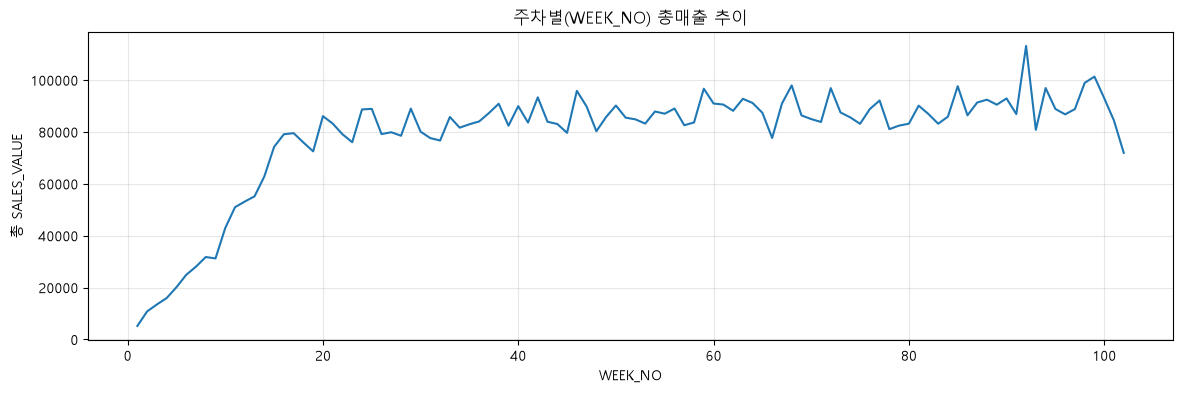

In [14]:
tx = dfs["transaction_data"]

# 주 단위 총매출 추이
weekly_sales = tx.groupby("WEEK_NO")["SALES_VALUE"].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(weekly_sales["WEEK_NO"], weekly_sales["SALES_VALUE"])
plt.title("주차별(WEEK_NO) 총매출 추이")
plt.xlabel("WEEK_NO")
plt.ylabel("총 SALES_VALUE")
plt.grid(alpha=0.3)
plt.show()


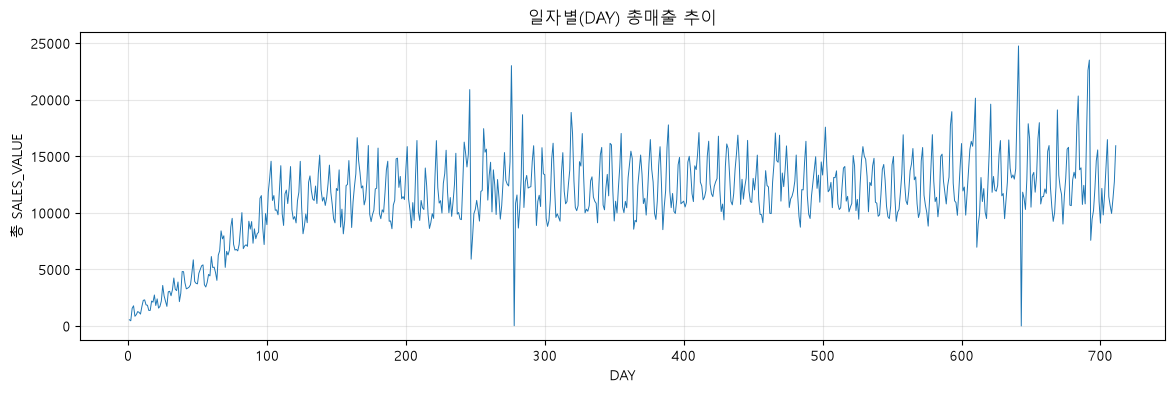

In [15]:
# 일 단위 총매출 추이 (노이즈 확인용)
daily_sales = tx.groupby("DAY")["SALES_VALUE"].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(daily_sales["DAY"], daily_sales["SALES_VALUE"], linewidth=0.7)
plt.title("일자별(DAY) 총매출 추이")
plt.xlabel("DAY")
plt.ylabel("총 SALES_VALUE")
plt.grid(alpha=0.3)
plt.show()


In [16]:
# 참고용 요약 통계
print("주차별 매출 요약 통계")
print(weekly_sales["SALES_VALUE"].describe())

print("\n최고 매출 주 top5")
print(weekly_sales.sort_values("SALES_VALUE", ascending=False).head())

print("\n최저 매출 주 top5")
print(weekly_sales.sort_values("SALES_VALUE", ascending=True).head())


주차별 매출 요약 통계
count       102.000000
mean      78994.736078
std       20944.795509
min        5211.160000
25%       79295.777500
50%       84936.740000
75%       89641.105000
max      113192.870000
Name: SALES_VALUE, dtype: float64

최고 매출 주 top5
    WEEK_NO  SALES_VALUE
91       92    113192.87
98       99    101363.92
97       98     98949.62
67       68     97967.05
84       85     97663.46

최저 매출 주 top5
   WEEK_NO  SALES_VALUE
0        1      5211.16
1        2     10821.35
2        3     13498.20
3        4     15965.99
4        5     20139.82


## 5. 활성 가구 수 / 방문(basket) 빈도 / 객단가 — 로직트리 3축 분포 확인

앞서 정의한 `총매출 = 활성 가구 수 × 가구당 평균 방문 횟수 × 방문당 평균 객단가` 분해를,
주 단위로 실제 계산해서 어느 축이 흔들리는지 대략 확인 (본 EDA는 다음 단계에서 진행).


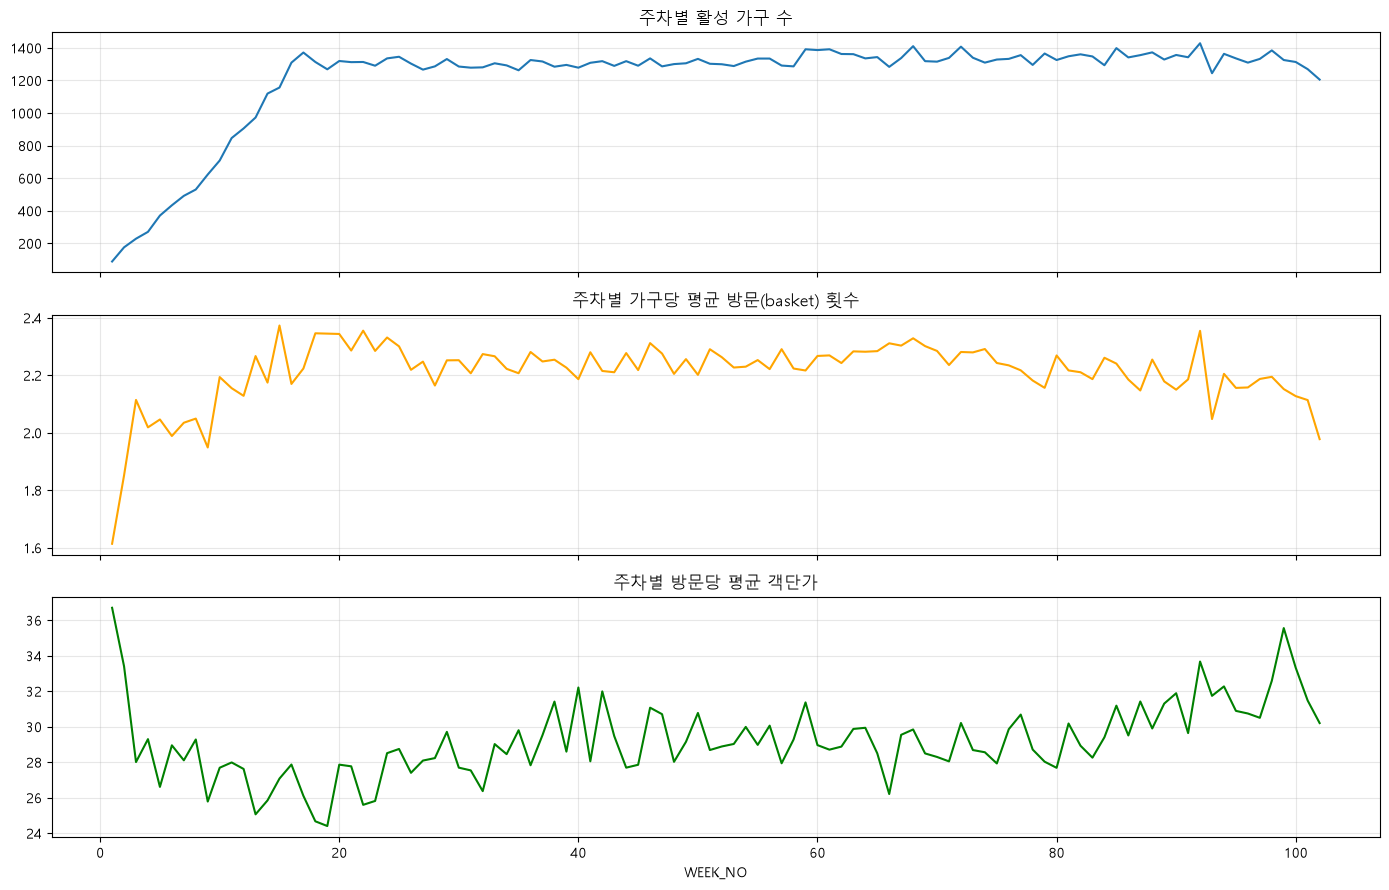

,WEEK_NO,active_households,n_baskets,total_sales,baskets_per_hh,sales_per_basket
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,51.500000,1215.450980,2710.627451,78994.736078,2.211060,29.171247
std,29.588849,291.568976,682.273775,20944.795509,0.108596,2.110866
min,1.000000,88.000000,142.000000,5211.160000,1.613636,24.398547
25%,26.250000,1284.250000,2841.250000,79295.777500,2.182335,27.947048
50%,51.500000,1313.000000,2936.000000,84936.740000,2.226481,28.935739
75%,76.750000,1337.750000,3005.750000,89641.105000,2.278718,30.194819
max,102.000000,1428.000000,3362.000000,113192.870000,2.372837,36.698310


In [17]:
weekly_metrics = tx.groupby("WEEK_NO").agg(
    active_households=("household_key", "nunique"),
    n_baskets=("BASKET_ID", "nunique"),
    total_sales=("SALES_VALUE", "sum"),
).reset_index()

weekly_metrics["baskets_per_hh"] = weekly_metrics["n_baskets"] / weekly_metrics["active_households"]
weekly_metrics["sales_per_basket"] = weekly_metrics["total_sales"] / weekly_metrics["n_baskets"]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(weekly_metrics["WEEK_NO"], weekly_metrics["active_households"])
axes[0].set_title("주차별 활성 가구 수")
axes[0].grid(alpha=0.3)

axes[1].plot(weekly_metrics["WEEK_NO"], weekly_metrics["baskets_per_hh"], color="orange")
axes[1].set_title("주차별 가구당 평균 방문(basket) 횟수")
axes[1].grid(alpha=0.3)

axes[2].plot(weekly_metrics["WEEK_NO"], weekly_metrics["sales_per_basket"], color="green")
axes[2].set_title("주차별 방문당 평균 객단가")
axes[2].set_xlabel("WEEK_NO")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

weekly_metrics.describe()


## 6. 수치형 핵심 분포 (히스토그램)

`SALES_VALUE`, `QUANTITY`는 극단값이 많은 컬럼이라 outlier 존재 여부만 우선 확인 (제거/처리는 본 EDA에서).


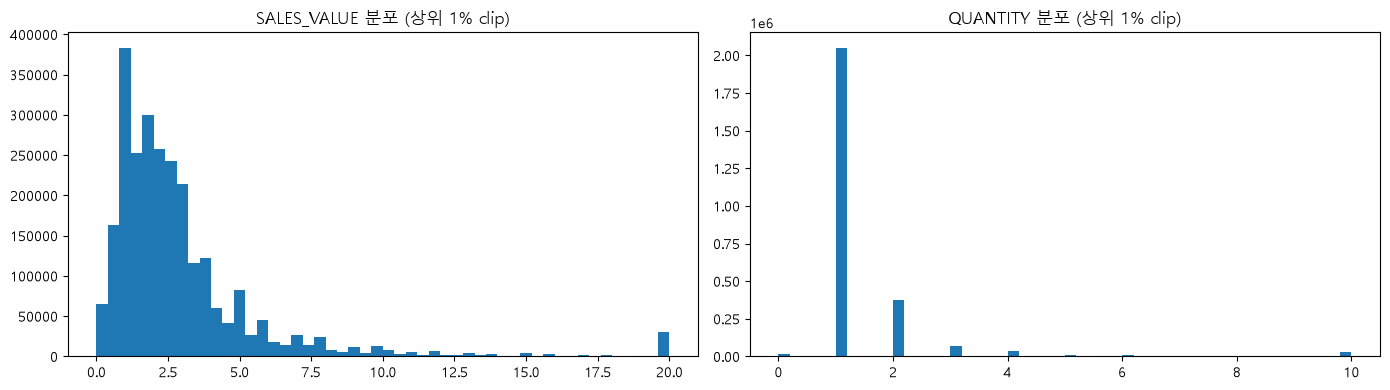

음수 SALES_VALUE 건수(환불 등 가능성): 0
0 QUANTITY 건수: 14466


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(tx["SALES_VALUE"].clip(upper=tx["SALES_VALUE"].quantile(0.99)), bins=50)
axes[0].set_title("SALES_VALUE 분포 (상위 1% clip)")

axes[1].hist(tx["QUANTITY"].clip(upper=tx["QUANTITY"].quantile(0.99)), bins=50)
axes[1].set_title("QUANTITY 분포 (상위 1% clip)")

plt.tight_layout()
plt.show()

print("음수 SALES_VALUE 건수(환불 등 가능성):", (tx["SALES_VALUE"] < 0).sum())
print("0 QUANTITY 건수:", (tx["QUANTITY"] == 0).sum())


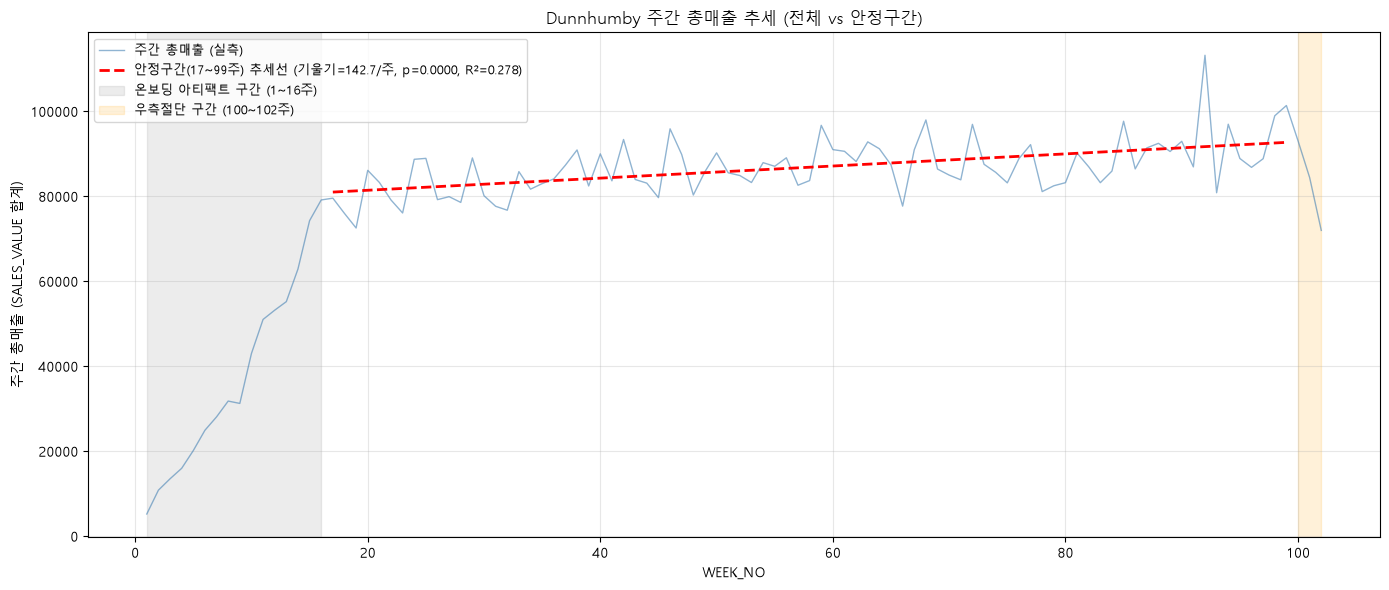

안정구간 회귀 기울기: 142.68 (주당 매출 변화액)
p-value: 0.000000  |  R²: 0.2782
추세선 기준 안정구간 내 총 변화율: 14.45%
안정구간 시작 주 매출(추세): 80,989
안정구간 끝 주 매출(추세): 92,690


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. 데이터 로드 (필요한 컬럼만)
tx = pd.read_csv("data/transaction_data.csv", usecols=["household_key", "WEEK_NO", "SALES_VALUE"])

# 2. 주차별 총매출 집계
weekly_rev = tx.groupby("WEEK_NO")["SALES_VALUE"].sum().reset_index()
weekly_rev = weekly_rev.sort_values("WEEK_NO")

# 3. 안정구간(17~99주) vs 전체 구분
stable = weekly_rev[(weekly_rev["WEEK_NO"] >= 17) & (weekly_rev["WEEK_NO"] <= 99)]

# 4. 안정구간 기준 선형회귀 (추세선)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    stable["WEEK_NO"], stable["SALES_VALUE"]
)
trend_line = slope * stable["WEEK_NO"] + intercept

# 5. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

# 전체 실제 매출 (얇은 선)
ax.plot(weekly_rev["WEEK_NO"], weekly_rev["SALES_VALUE"],
        color="steelblue", linewidth=1, alpha=0.6, label="주간 총매출 (실측)")

# 안정구간 추세선 (굵은 점선)
ax.plot(stable["WEEK_NO"], trend_line,
        color="red", linewidth=2, linestyle="--",
        label=f"안정구간(17~99주) 추세선 (기울기={slope:.1f}/주, p={p_value:.4f}, R²={r_value**2:.3f})")

# 제외 구간 음영 처리
ax.axvspan(weekly_rev["WEEK_NO"].min(), 16, color="gray", alpha=0.15, label="온보딩 아티팩트 구간 (1~16주)")
ax.axvspan(100, weekly_rev["WEEK_NO"].max(), color="orange", alpha=0.15, label="우측절단 구간 (100~102주)")

ax.set_xlabel("WEEK_NO")
ax.set_ylabel("주간 총매출 (SALES_VALUE 합계)")
ax.set_title("Dunnhumby 주간 총매출 추세 (전체 vs 안정구간)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("weekly_revenue_trend.png", dpi=150)
plt.show()

# 6. 숫자로도 확인
total_weeks = stable["WEEK_NO"].max() - stable["WEEK_NO"].min()
pct_change = (trend_line.iloc[-1] - trend_line.iloc[0]) / trend_line.iloc[0] * 100
print(f"안정구간 회귀 기울기: {slope:.2f} (주당 매출 변화액)")
print(f"p-value: {p_value:.6f}  |  R²: {r_value**2:.4f}")
print(f"추세선 기준 안정구간 내 총 변화율: {pct_change:.2f}%")
print(f"안정구간 시작 주 매출(추세): {trend_line.iloc[0]:,.0f}")
print(f"안정구간 끝 주 매출(추세): {trend_line.iloc[-1]:,.0f}")